<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 8</b></center>    
<pre>    

# import necessary libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
import warnings 
warnings.filterwarnings('ignore')

# Import diabetes.csv data ser using sklearn

In [2]:
df=pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,Diabetic
1,1,85,66,29,0,26.6,0.351,31,Non Diabetic
2,8,183,64,0,0,23.3,0.672,32,Diabetic
3,1,89,66,23,94,28.1,0.167,21,Non Diabetic
4,0,137,40,35,168,43.1,2.288,33,Diabetic


# Check the distribution of the target

In [4]:
print(df['Outcome'].value_counts())

Outcome
Non Diabetic    500
Diabetic        268
Name: count, dtype: int64


# Replace zeros with NaN for specific columns

In [7]:
cols=['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

df[cols]=df[cols].replace(0,np.nan)


# Check for missing values

In [ ]:
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

# Fill missing values with median

In [19]:
for col in cols:
 df[col]=df[col].fillna(df[col].median())

    

In [20]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

# Visualize Distributions

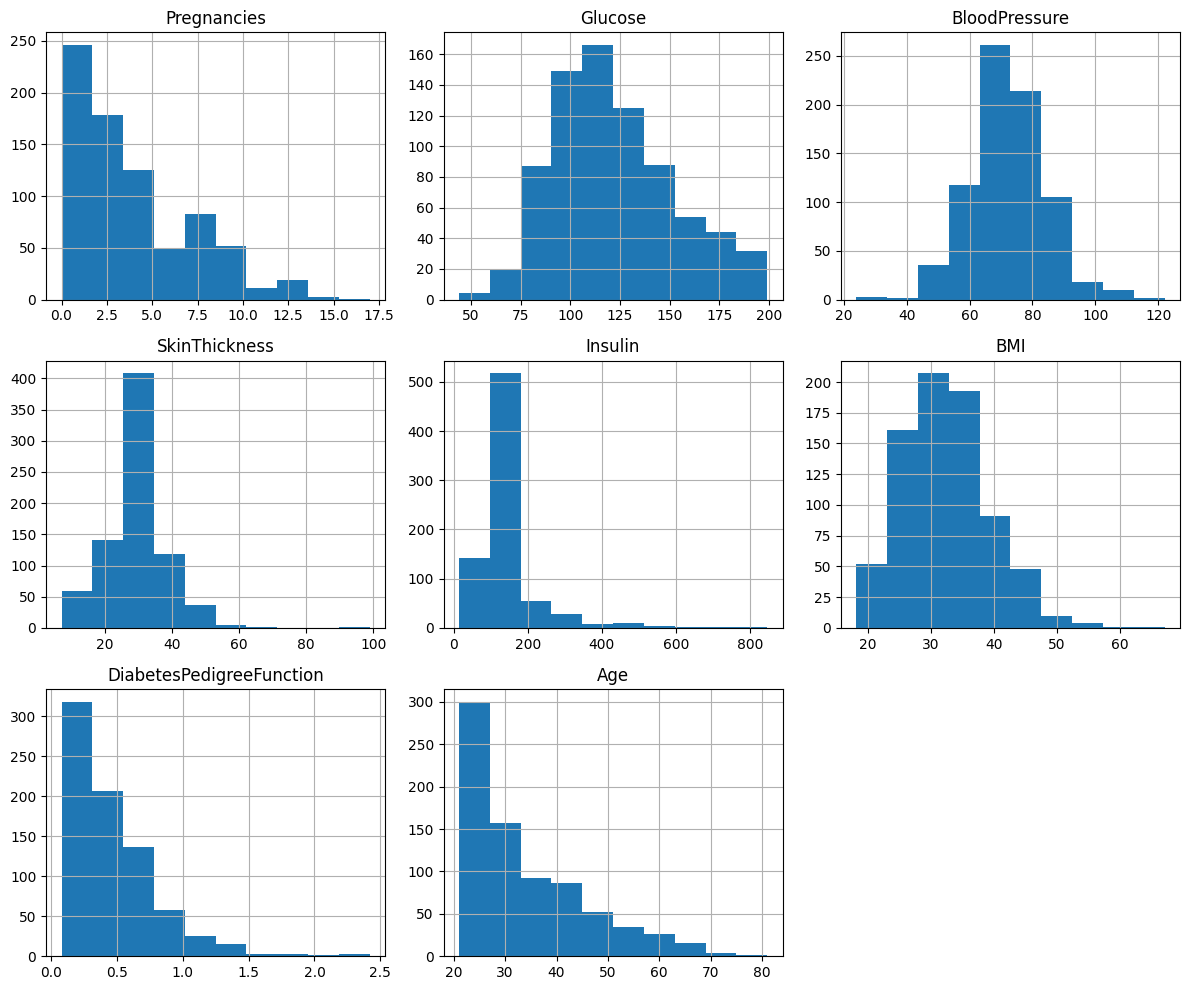

In [21]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

In [23]:
df['Outcome'].unique()

array([0, 1])

# Convert Targer data into interger code

In [22]:
le=LabelEncoder()
df['Outcome']=le.fit_transform(df['Outcome'])

# Divide the data into input and output

In [24]:
X=df.drop('Outcome',axis=1)
y=df['Outcome']

print(X.shape)
print(y.shape)

(768, 8)
(768,)


# Splitting the dataset into the Training set and Test set

In [25]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [26]:
X_train.shape

(614, 8)

In [27]:
X_test.shape

(154, 8)

# Create Model

In [28]:
model = DecisionTreeClassifier(max_depth=2,random_state=42)

# Fitting DecisionTreeClassifier   on dataset

In [29]:
model.fit(X_train,y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

# Display Decision Tree

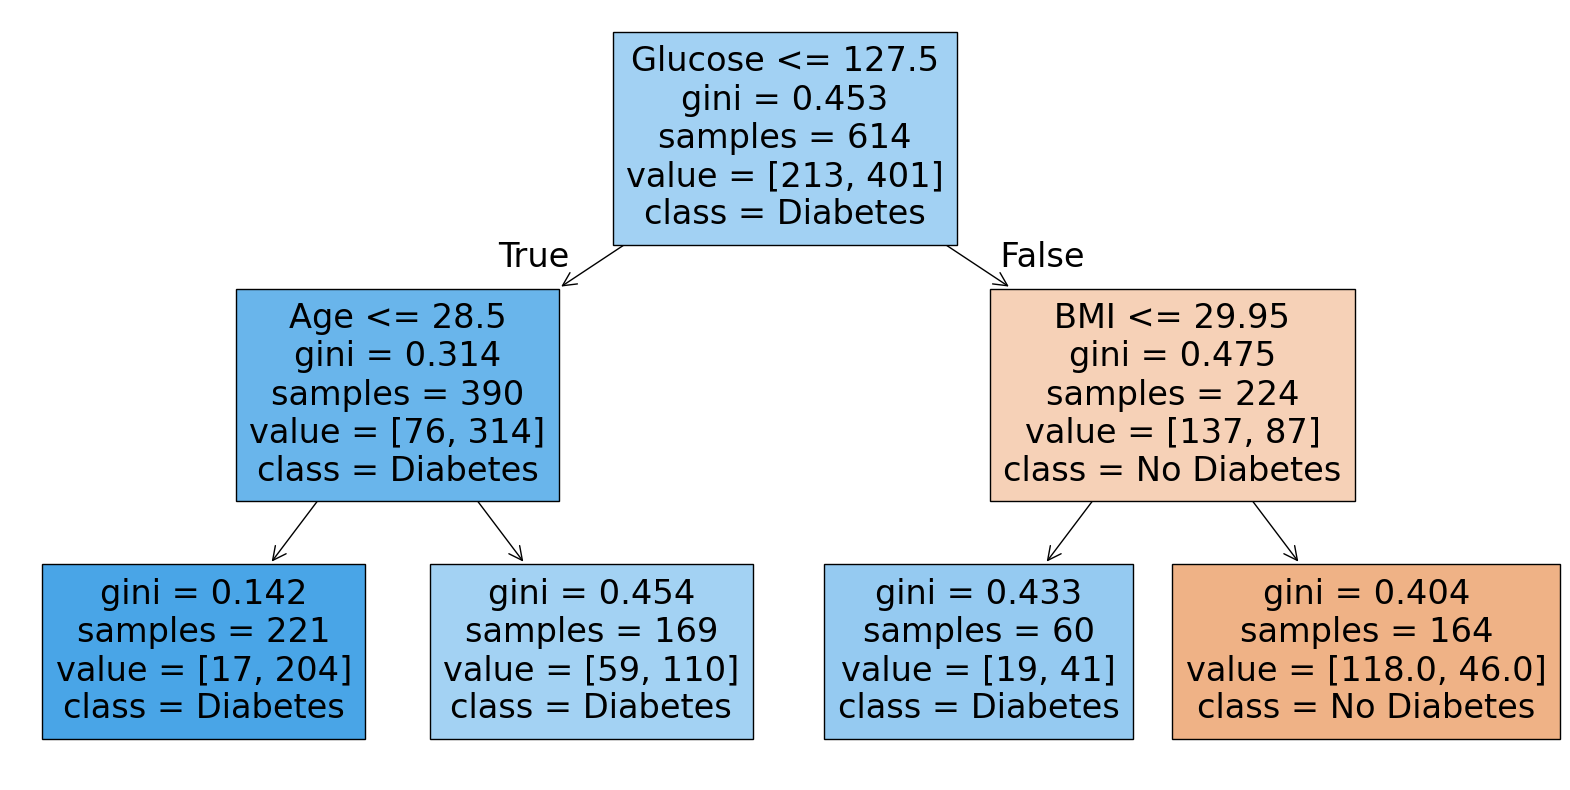

In [30]:
plt.figure(figsize=(20,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['No Diabetes','Diabetes'],
    filled=True

)

plt.show()

# Predict the x_test 

In [31]:
y_pred=model.predict(X_test)
print(y_pred)

[1 1 1 1 1 1 1 1 0 0 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 0 0 0 0 1 0 0
 1 1 0 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 0 1 0 1 0 0 1 1 1
 1 1 1 1 1 1 0 1 1 0 1 0 0 1 1 1 1 1 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 0 1 1 1
 1 1 0 1 1 0 1 1 1 1 1 1 1 1 1 1 0 0 1 1 0 1 1 0 1 1 0 0 1 1 1 1 0 1 1 1 1
 1 0 1 1 1 1]


# Display Training Accuracy

In [33]:
Training=model.score(X_train,y_train)
print('Training accuracy : ',Training)

Training accuracy :  0.7703583061889251


# Display Test Accuracy

In [34]:
Testing=model.score(X_test,y_test)
print('Testing accuracy : ',Testing)

Testing accuracy :  0.7727272727272727
